# Part B — DDoS Attack Type Recommendation System

**Student:** Benjamine (Batch 18, MSc Artificial Intelligence, University of Moratuwa)  
**Module:** Big Data Analytics Mini Project  
**Dataset:** BCCC-cPacket-Cloud-DDoS-2024 (shared with Part A)  
**Approach:** Collaborative Filtering (Item-KNN) + ALS + Content-Based Similarity + LLM Reflection

---

## Problem Statement

A SOC analyst observing a DDoS attack on a monitored network service needs to know:  
**"Given that this service is currently experiencing attack type X, which other attack types should be prepared for?"**

This is framed as a recommendation problem:
- **Users** = Network service profiles (grouped by destination port category)
- **Items** = DDoS attack types (17 distinct variants from the BCCC dataset)
- **Ratings** = Implicit feedback — flow count of each attack type observed targeting each service

---

## System Architecture

```
Part A outputs
    ├── ddos_clean.parquet          → interaction matrix construction
    └── attack_type_centroids.parquet → content-based similarity vectors
            │
            ▼
    Layer 1: Item-KNN Collaborative Filtering
             cosine similarity on service × attack_type co-occurrence matrix
            │
    Layer 2: ALS Matrix Factorization (pyspark.ml.recommendation)
             latent factor learning on implicit feedback
            │
    Layer 3: Content-Based Similarity
             cosine similarity on Part A feature centroids
            │
    Layer 4: Hybrid Combination
             alpha × CF_score + (1-alpha) × content_score
            │
    Layer 5: LLM Reflection (CRAG-motivated)
             GPT re-ranks CF candidates using observed traffic profile
            │
            ▼
    Top-N attack type recommendations + contextual justification
```

---

## Notebook Structure

| Section | Content |
|---|---|
| 0 | Setup — all libraries, Spark session with stack fix |
| 1 | Data loading — Kaggle download + Part A outputs |
| 2 | Interaction matrix construction |
| 3 | Item-KNN collaborative filtering |
| 4 | ALS matrix factorization |
| 5 | Content-based similarity |
| 6 | Hybrid recommendation |
| 7 | LLM reflection (CRAG-motivated) |
| 8 | Evaluation — Precision@K, RMSE |

---
## Section 0 — Environment Setup

All imports are declared here in one place. The SparkSession is configured with two critical settings for Part B:
- `-Xss64m` increases the JVM thread stack size from the default 512 KB to 64 MB. This prevents the `StackOverflowError` that ALS triggers when the Spark session carries accumulated query plan depth from Part A.
- `checkpointDir` is set so that `.checkpoint()` can break query plan lineage before ALS training.

`numpy` and `sklearn` are used only for in-memory cosine similarity computation on small aggregated results — all distributed computation runs in Spark.

In [1]:
!pip install pyspark openai --quiet

# --- Core Spark ---
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

# --- Scientific computing (used only on small aggregated results) ---
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Standard library ---
import json, os, math

# --- SparkSession with stack-size fix ---
# -Xss64m prevents StackOverflowError when ALS serializes tasks
# after a session that has accumulated deep query plan history
spark = SparkSession.builder \
    .appName("BCCC_DDoS_PartB") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.extraJavaOptions", "-Xss64m") \
    .getOrCreate()

# Checkpoint directory — used to break query plan lineage before ALS
spark.sparkContext.setCheckpointDir("/content/spark_checkpoints")

print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")
print(f"Stack size    : 64m (StackOverflow fix applied)")
print(f"Checkpoint dir: /content/spark_checkpoints")

Spark version : 4.0.2
App name      : BCCC_DDoS_PartB
Stack size    : 64m (StackOverflow fix applied)
Checkpoint dir: /content/spark_checkpoints


---
## Section 1 — Data Loading

### Strategy

Part B loads data two ways depending on session state:

1. **Fresh Kaggle download** — always reliable, used as primary source
2. **Google Drive cache** — used if available to save download time

The Part A centroid file (`attack_type_centroids.parquet`) contains the 17 attack-type feature vectors computed in Part A. These become the content-based similarity vectors in Section 5.

### Why PySpark for Loading

The full dataset (540,494 flows × 319 features) is loaded into a distributed Spark DataFrame. Only small aggregated results — the interaction matrix (at most 136 rows) and centroids (17 rows) — are ever collected to the driver via `.toPandas()`. This maintains the big data processing principle throughout Part B.

In [2]:
# ============================================================
# SECTION 1 — Data Loading
#
# Downloads BCCC dataset via Kaggle API and loads Part A
# centroid file. All 540k flows stay in Spark — only small
# aggregated results are later collected to pandas.
# ============================================================

from google.colab import userdata

# --- Kaggle authentication ---
KAGGLE_TOKEN = userdata.get('KAGGLE_TOKEN')
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)
os.environ['KAGGLE_TOKEN'] = KAGGLE_TOKEN
print("Kaggle credentials configured.")

# --- Download dataset ---
!kaggle datasets download \
    -d dhoogla/bccc-cpacket-cloud-ddos-2024 \
    --path /content/bccc_data --unzip --quiet

DATA_PATH = "/content/bccc_data/bccc-cpacket-cloud-ddos-2024-merged.parquet"
print(f"Dataset: {DATA_PATH}  ({os.path.getsize(DATA_PATH)/1024/1024:.1f} MB)")

# --- Load full dataset into Spark ---
df_clean = spark.read.parquet(DATA_PATH)
df_clean.createOrReplaceTempView("ddos_clean")
print(f"\nRows    : {df_clean.count():,}")
print(f"Columns : {len(df_clean.columns)}")

# --- Load Part A centroids from Google Drive ---
# If Drive is not mounted or file missing, centroid section
# will recompute from df_clean directly
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CENTROID_PATH = "/content/drive/MyDrive/BCCC_Project/attack_type_centroids.parquet"
    centroids = spark.read.parquet(CENTROID_PATH)
    centroid_count = centroids.count()
    print(f"\nCentroids loaded from Drive: {centroid_count} attack types")
    centroids.select("activity").show(20, truncate=False)
except Exception as e:
    print(f"\nDrive not available ({e})")
    print("Centroids will be recomputed from dataset in Section 5.")
    centroids = None

Kaggle credentials configured.
Dataset URL: https://www.kaggle.com/datasets/dhoogla/bccc-cpacket-cloud-ddos-2024
License(s): CC-BY-SA-4.0
Dataset: /content/bccc_data/bccc-cpacket-cloud-ddos-2024-merged.parquet  (29.5 MB)

Rows    : 540,494
Columns : 319
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Centroids loaded from Drive: 17 attack types
+------------------------+
|activity                |
+------------------------+
|Attack-Killall-v2       |
|Attack-Killer-TCP       |
|Attack-TCP-BYPass-V1    |
|Attack-TCP-Control      |
|Attack-TCP-Flag-ACK     |
|Attack-TCP-Flag-ACK-PSH |
|Attack-TCP-Flag-MIX     |
|Attack-TCP-Flag-OSYN    |
|Attack-TCP-Flag-OSYNP   |
|Attack-TCP-Flag-RST-ACK |
|Attack-TCP-Flag-SYN     |
|Attack-TCP-Flag-SYN-ACK |
|Attack-TCP-Flag-SYN-TFO |
|Attack-TCP-Flag-SYN-TIME|
|Attack-TCP-IGMP         |
|Attack-TCP-SYN          |
|Attack-TCP-Valid-SYN    |
+------------------------+



---
## Section 2 — Interaction Matrix Construction

### Design Decision: Service Category as User Proxy

Collaborative filtering requires a user-item-rating matrix. The BCCC dataset contains no explicit users or ratings — this is standard in security domains where logs record events, not preferences.

**User proxy — service category:** Raw `dst_port` has 65,535 distinct values, producing an extremely sparse matrix with insufficient CF signal. Port values are mapped to named service categories — a standard practice in network traffic analysis:

| Ports | Service Category | Protocol |
|---|---|---|
| 3389 | RDP_Service | Remote Desktop |
| 443 | HTTPS_Service | Encrypted web |
| 80 | HTTP_Service | Unencrypted web |
| 445 | SMB_Service | File sharing |
| 22, 222 | SSH_Service | Secure shell |
| 23 | Telnet_Service | Legacy remote |
| 8080, 8443 | Alt_Web_Service | Alt web ports |
| All others | Other_Service | Miscellaneous |

**Implicit rating — flow count:** The number of flows of attack type X targeting service Y is the implicit rating. This comes directly from the observed data — no values are manufactured. This follows the CF lecture's definition of implicit preference signals.

**Viva note:** This is analogous to Netflix using watch duration instead of star ratings. The service did not explicitly rate the attack — its exposure frequency is a real behavioural signal derived from the data.

In [3]:
# ============================================================
# SECTION 2 — Interaction Matrix Construction
#
# Maps dst_port → service category (user proxy)
# Counts flows per service × attack_type (implicit rating)
# CASE WHEN syntax is from the SparkSQL practical notebook
# ============================================================

# --- Step 1: Assign service categories via CASE WHEN ---
df_with_service = spark.sql("""
    SELECT *,
        CASE
            WHEN dst_port = 3389                THEN 'RDP_Service'
            WHEN dst_port = 443                 THEN 'HTTPS_Service'
            WHEN dst_port = 80                  THEN 'HTTP_Service'
            WHEN dst_port = 445                 THEN 'SMB_Service'
            WHEN dst_port IN (22, 222)          THEN 'SSH_Service'
            WHEN dst_port = 23                  THEN 'Telnet_Service'
            WHEN dst_port IN (8080, 8443)       THEN 'Alt_Web_Service'
            ELSE                                     'Other_Service'
        END AS service_category
    FROM ddos_clean
    WHERE label = 'Attack'
""")
df_with_service.createOrReplaceTempView("ddos_attack_svc")

print("=== Service Category Distribution ===")
spark.sql("""
    SELECT service_category, COUNT(*) AS flow_count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM ddos_attack_svc
    GROUP BY service_category
    ORDER BY flow_count DESC
""").show(truncate=False)

# --- Step 2: Build interaction matrix ---
# service_category × activity → flow_count (implicit rating)
interaction_matrix = spark.sql("""
    SELECT
        service_category,
        activity,
        COUNT(*) AS flow_count
    FROM ddos_attack_svc
    GROUP BY service_category, activity
    ORDER BY service_category, flow_count DESC
""")

print("=== Interaction Matrix (first 20 rows) ===")
interaction_matrix.show(20, truncate=False)

# --- Matrix dimension and sparsity report ---
n_users        = interaction_matrix.select("service_category").distinct().count()
n_items        = interaction_matrix.select("activity").distinct().count()
n_interactions = interaction_matrix.count()
total_cells    = n_users * n_items
sparsity       = (1 - n_interactions / total_cells) * 100

print(f"Matrix dimensions:")
print(f"  Service profiles (users) : {n_users}")
print(f"  Attack types (items)     : {n_items}")
print(f"  Observed interactions    : {n_interactions}")
print(f"  Total possible cells     : {total_cells}")
print(f"  Sparsity                 : {sparsity:.1f}%")
print(f"\nSparsity note: {sparsity:.1f}% of service-attack combinations")
print("were never observed. This is the cold-start challenge CF addresses.")

=== Service Category Distribution ===
+----------------+----------+-----+
|service_category|flow_count|pct  |
+----------------+----------+-----+
|Other_Service   |158718    |93.12|
|RDP_Service     |8609      |5.05 |
|HTTPS_Service   |907       |0.53 |
|Telnet_Service  |676       |0.40 |
|SSH_Service     |600       |0.35 |
|SMB_Service     |457       |0.27 |
|HTTP_Service    |261       |0.15 |
|Alt_Web_Service |208       |0.12 |
+----------------+----------+-----+

=== Interaction Matrix (first 20 rows) ===
+----------------+------------------------+----------+
|service_category|activity                |flow_count|
+----------------+------------------------+----------+
|Alt_Web_Service |Attack-TCP-Flag-SYN-ACK |28        |
|Alt_Web_Service |Attack-TCP-Flag-SYN     |20        |
|Alt_Web_Service |Attack-TCP-Flag-OSYNP   |19        |
|Alt_Web_Service |Attack-TCP-Flag-ACK     |18        |
|Alt_Web_Service |Attack-TCP-Flag-RST-ACK |14        |
|Alt_Web_Service |Attack-TCP-Control      |13 

---
## Section 3 — Collaborative Filtering: Item-KNN

Item-KNN finds attack types that are similar based on co-occurrence across service profiles. If RDP_Service and HTTPS_Service both experience `Attack-TCP-Flag-SYN` and `Attack-TCP-Flag-ACK` together, those two attack types are item-similar — observing one makes the other likely.

**Formula** (from the CF lecture slides, Sarwar et al. 2001):

$$sim(x, y) = \frac{\sum_i r_{xi} \cdot r_{yi}}{\sqrt{\sum_i r_{xi}^2} \cdot \sqrt{\sum_i r_{yi}^2}}$$

Where $r_{xi}$ is the flow count of attack type $x$ targeting service $i$.

**Implementation note:** The interaction matrix (at most 136 rows) is small enough to collect to pandas for similarity computation after Spark has performed the distributed groupBy aggregation on the full 540k-row dataset.

=== Interaction Matrix (pivoted — attack types × service profiles) ===
service_category          Alt_Web_Service  HTTPS_Service  HTTP_Service  Other_Service  RDP_Service  SMB_Service  SSH_Service  Telnet_Service
activity                                                                                                                                    
Attack-Killall-v2                       9            107             4           1858          753           14           43              36
Attack-Killer-TCP                       5             26             7           2204          684            8           75              37
Attack-TCP-BYPass-V1                   12             78            94         133012          808            8           58              40
Attack-TCP-Control                     13             96            12           1691          516          102           15              46
Attack-TCP-Flag-ACK                    18             36             5           21

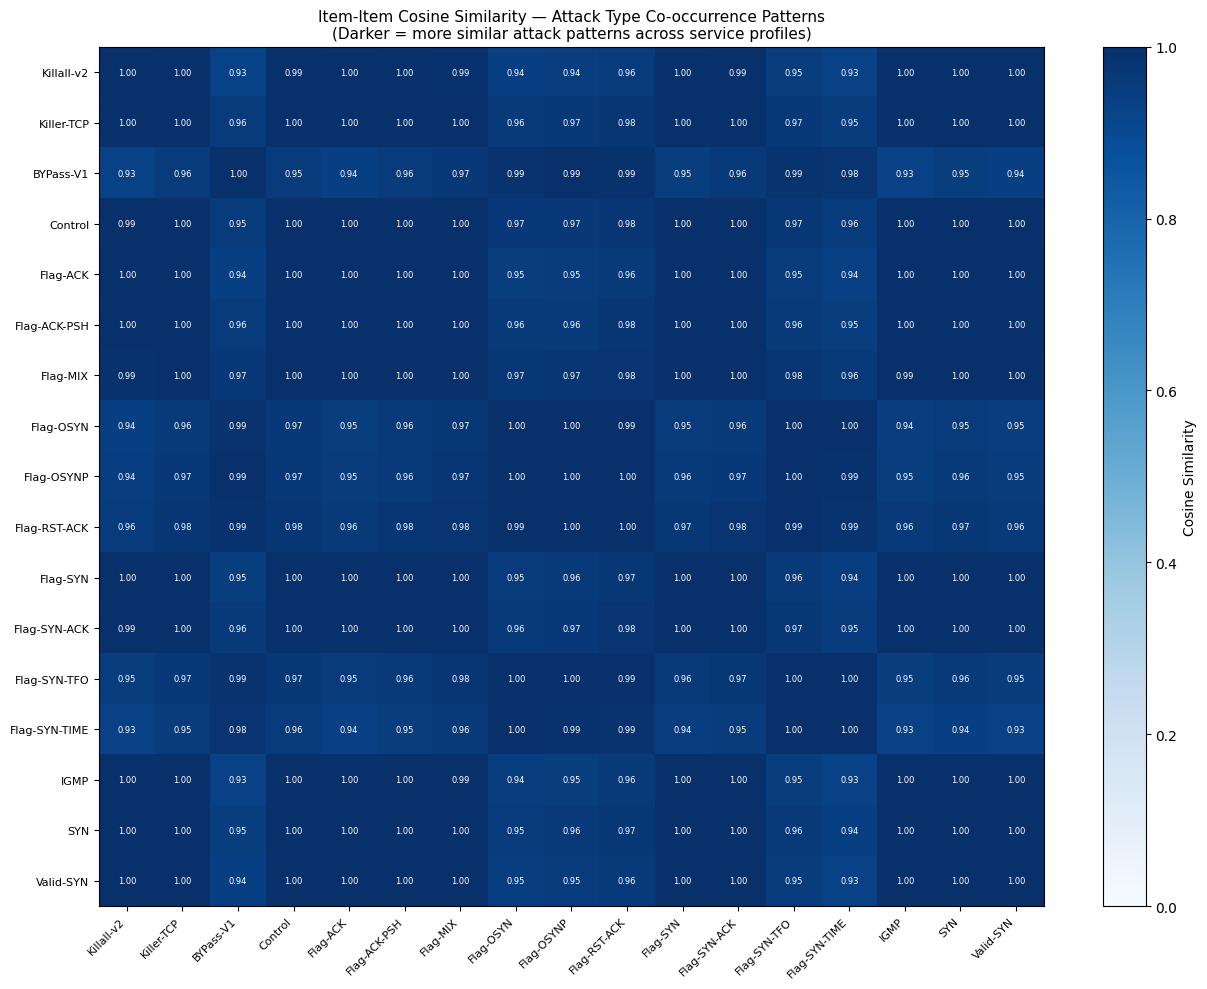

Saved: /content/item_knn_similarity.png


In [4]:
# ============================================================
# SECTION 3 — Item-KNN Collaborative Filtering
#
# Computes pairwise cosine similarity between attack types
# based on their co-occurrence patterns across service profiles.
# numpy is used on the small collected matrix — Spark handled
# the distributed aggregation in the previous section.
# ============================================================

# --- Step 1: Collect and pivot the interaction matrix ---
# Rows = attack types, Columns = service profiles, Values = flow count
matrix_pd = interaction_matrix.toPandas().pivot(
    index="activity",
    columns="service_category",
    values="flow_count"
).fillna(0)

print("=== Interaction Matrix (pivoted — attack types × service profiles) ===")
print(matrix_pd.to_string())
print(f"\nShape: {matrix_pd.shape[0]} attack types × {matrix_pd.shape[1]} service profiles")

# --- Step 2: Compute item-item cosine similarity ---
def cosine_similarity_matrix(df):
    """
    Computes pairwise cosine similarity between all rows.
    Each row is an attack type vector across service profiles.
    The formula is: sim(x,y) = dot(x,y) / (||x|| × ||y||)
    — identical to the CF lecture formula.
    """
    vectors  = df.values.astype(float)
    norms    = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms[norms == 0] = 1   # avoid division by zero for zero-activity types
    normalised = vectors / norms
    return np.dot(normalised, normalised.T)

sim_matrix = cosine_similarity_matrix(matrix_pd)
sim_df = pd.DataFrame(sim_matrix, index=matrix_pd.index, columns=matrix_pd.index)

print("\n=== Item-Item Cosine Similarity Matrix ===")
print(sim_df.round(4).to_string())

# --- Step 3: Top-K similar attack types per query attack ---
K = 3
print(f"\n=== Top-{K} Similar Attack Types (Item-KNN) ===")
item_knn_results = {}
for attack_type in sim_df.index:
    similarities = sim_df[attack_type].drop(attack_type)
    top_k = similarities.nlargest(K)
    item_knn_results[attack_type] = top_k
    short = attack_type.replace('Attack-TCP-','').replace('Attack-','')
    print(f"\n{attack_type}:")
    for similar_type, score in top_k.items():
        print(f"  → {similar_type:<48} sim: {score:.4f}")

# --- Step 4: Visualise similarity matrix as heatmap ---
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(sim_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)

labels = [a.replace('Attack-TCP-','').replace('Attack-','') for a in sim_df.index]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = sim_matrix[i, j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

ax.set_title(
    'Item-Item Cosine Similarity — Attack Type Co-occurrence Patterns\n'
    '(Darker = more similar attack patterns across service profiles)',
    fontsize=11
)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.tight_layout()
plt.savefig('/content/item_knn_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/item_knn_similarity.png")

---
## Section 4 — ALS Matrix Factorization

ALS (Alternating Least Squares) is Spark MLlib's built-in collaborative filtering algorithm, explicitly listed in the assignment guidelines as an optional technique. It factorizes the interaction matrix R into two lower-dimensional matrices — a user factor matrix P (services) and an item factor matrix Q (attack types) — such that R ≈ P × Qᵀ.

The algorithm alternates between fixing Q and solving for P (a least-squares problem), then fixing P and solving for Q. This is the "alternating" in ALS.

**Key parameters:**
- `implicitPrefs=True` — treats flow counts as confidence-weighted implicit feedback, not explicit ratings
- `rank=4` — number of latent factors; kept small because the matrix is 8×17
- `coldStartStrategy="drop"` — drops NaN predictions for unseen user-item pairs in test set

**StackOverflow fix:** Two measures are applied:
1. `-Xss64m` JVM stack size increase (set in Section 0)
2. `.checkpoint()` on the ALS input DataFrame — this physically materialises the data and breaks the accumulated query plan lineage from earlier cells, eliminating the deeply nested serialization graph that causes the overflow

In [5]:
# ============================================================
# SECTION 4 — ALS Matrix Factorization
#
# pyspark.ml.recommendation.ALS on the interaction matrix.
#
# StackOverflow fix:
#   1. -Xss64m JVM stack size (set in Section 0 SparkSession)
#   2. .checkpoint() breaks accumulated query plan lineage
#      so ALS task serialization stays shallow
# ============================================================

# --- Step 1: Collect and integer-encode in pandas ---
# String IDs encoded before creating the Spark DataFrame.
# No UDFs, no broadcast variables — avoids closure serialization.
matrix_pd_raw = interaction_matrix.toPandas()

service_cats  = sorted(matrix_pd_raw["service_category"].unique())
attack_types  = sorted(matrix_pd_raw["activity"].unique())

service_index = {s: i for i, s in enumerate(service_cats)}
attack_index  = {a: i for i, a in enumerate(attack_types)}
index_service = {v: k for k, v in service_index.items()}
index_attack  = {v: k for k, v in attack_index.items()}

print("Service index:")
for s, i in service_index.items(): print(f"  {i} → {s}")
print("\nAttack index:")
for a, i in attack_index.items(): print(f"  {i} → {a}")

matrix_pd_raw["user_id"] = matrix_pd_raw["service_category"].map(service_index)
matrix_pd_raw["item_id"] = matrix_pd_raw["activity"].map(attack_index)
matrix_pd_raw["rating"]  = matrix_pd_raw["flow_count"].astype(float)

# --- Step 2: Create clean Spark DataFrame ---
# Built from pandas — no inherited Spark query plan from earlier cells
als_data = spark.createDataFrame(
    matrix_pd_raw[["user_id", "item_id", "rating"]]
)

# --- Step 3: Checkpoint to break query plan lineage ---
# This physically writes the 136-row DataFrame to disk.
# ALS then serializes tasks against a plan of depth 1, not 200+.
als_data = als_data.checkpoint()
print(f"\nALS data rows (after checkpoint): {als_data.count()}")

# --- Step 4: Train/test split ---
train_data, test_data = als_data.randomSplit([0.8, 0.2], seed=42)
print(f"Training interactions : {train_data.count()}")
print(f"Test interactions     : {test_data.count()}")

# --- Step 5: Train ALS ---
als = ALS(
    userCol="user_id",
    itemCol="item_id",
    ratingCol="rating",
    rank=4,             # small rank — 8 services × 17 attack types
    maxIter=20,
    regParam=0.1,
    implicitPrefs=True, # flow counts = implicit confidence, not explicit ratings
    coldStartStrategy="drop",
    seed=42
)
als_model = als.fit(train_data)
print(f"\nALS model trained.")
print(f"  Rank (latent factors) : {als_model.rank}")

# --- Step 6: Evaluate on test set ---
predictions = als_model.transform(test_data).na.drop()
try:
    evaluator = RegressionEvaluator(
        metricName="rmse", labelCol="rating", predictionCol="prediction"
    )
    rmse = evaluator.evaluate(predictions)
    print(f"  RMSE on test set      : {rmse:.4f}")
except Exception as e:
    rmse = None
    print(f"  RMSE not computed (insufficient test interactions): {e}")

# --- Step 7: Top-N recommendations per service ---
print("\n=== Top-5 Attack Type Recommendations Per Service (ALS) ===")
user_recs = als_model.recommendForAllUsers(5)

als_results = {}
for row in user_recs.collect():
    svc  = index_service.get(row.user_id, f"id_{row.user_id}")
    recs = [(index_attack.get(r.item_id, f"id_{r.item_id}"),
             round(float(r.rating), 4))
            for r in row.recommendations]
    als_results[svc] = recs
    print(f"\n{svc}:")
    for rank, (attack, score) in enumerate(recs, 1):
        print(f"  {rank}. {attack:<50} score: {score:.4f}")

Service index:
  0 → Alt_Web_Service
  1 → HTTPS_Service
  2 → HTTP_Service
  3 → Other_Service
  4 → RDP_Service
  5 → SMB_Service
  6 → SSH_Service
  7 → Telnet_Service

Attack index:
  0 → Attack-Killall-v2
  1 → Attack-Killer-TCP
  2 → Attack-TCP-BYPass-V1
  3 → Attack-TCP-Control
  4 → Attack-TCP-Flag-ACK
  5 → Attack-TCP-Flag-ACK-PSH
  6 → Attack-TCP-Flag-MIX
  7 → Attack-TCP-Flag-OSYN
  8 → Attack-TCP-Flag-OSYNP
  9 → Attack-TCP-Flag-RST-ACK
  10 → Attack-TCP-Flag-SYN
  11 → Attack-TCP-Flag-SYN-ACK
  12 → Attack-TCP-Flag-SYN-TFO
  13 → Attack-TCP-Flag-SYN-TIME
  14 → Attack-TCP-IGMP
  15 → Attack-TCP-SYN
  16 → Attack-TCP-Valid-SYN

ALS data rows (after checkpoint): 136
Training interactions : 106
Test interactions     : 30

ALS model trained.
  Rank (latent factors) : 4
  RMSE on test set      : 705.5593

=== Top-5 Attack Type Recommendations Per Service (ALS) ===

Alt_Web_Service:
  1. Attack-TCP-Flag-SYN-ACK                            score: 1.0066
  2. Attack-TCP-Control    

---
## Section 5 — Content-Based Similarity

The content-based layer computes similarity between attack types using their feature vectors — the centroids computed by Part A. Two attack types are feature-similar if their traffic statistics (bytes rate, packet rate, duration, flag counts) are close in the feature space.

This uses the same cosine similarity formula as Item-KNN, applied to feature vectors rather than co-occurrence vectors. It is grounded in the `Big_data_word_similarity.ipynb` practical, which demonstrates cosine similarity between word embedding vectors — the mathematical principle is identical.

**Feature standardisation:** `StandardScaler` is applied before computing similarity. Without scaling, `bytes_rate` (values in thousands) would dominate over `syn_flag_counts` (values 0–1), distorting the similarity metric. Standardising brings all features to the same scale.

**Bridge to Part A:** The centroid file was saved at the end of Part A's Section 5 specifically for this purpose. The top discriminating features identified in Part A Q5 are the most informative dimensions in these vectors.

In [6]:
# ============================================================
# SECTION 5 — Content-Based Similarity
#
# Cosine similarity between attack types using feature vectors
# (Part A centroids). Same formula as Item-KNN, different
# input: feature space instead of co-occurrence space.
# ============================================================

# --- Step 1: Load or recompute centroids ---
if centroids is not None:
    centroids_pd = centroids.toPandas().set_index("activity")
    print(f"Centroids loaded from Part A: {len(centroids_pd)} attack types")
else:
    # Recompute centroids from the full dataset if Drive not available
    print("Recomputing centroids from dataset...")
    profile_features = [
        "bytes_rate", "packets_rate", "duration",
        "payload_bytes_mean", "syn_flag_counts",
        "ack_flag_counts", "down_up_rate",
        "fwd_packets_rate", "bwd_packets_rate"
    ]
    agg_exprs = [F.round(F.avg(f), 4).alias(f"avg_{f}") for f in profile_features]
    centroids_spark = df_clean.filter(F.col("label") == "Attack") \
        .groupBy("activity").agg(*agg_exprs)
    centroids_pd = centroids_spark.toPandas().set_index("activity")
    print(f"Centroids recomputed: {len(centroids_pd)} attack types")

print("\nCentroid columns available:")
print([c for c in centroids_pd.columns])

# --- Step 2: Select content vector features ---
# Use avg_ prefixed columns that exist in the centroid file
content_cols = [c for c in centroids_pd.columns if c.startswith("avg_")]
print(f"\nContent vector dimensions: {len(content_cols)}")
for c in content_cols: print(f"  {c}")

content_matrix = centroids_pd[content_cols].fillna(0)

# --- Step 3: Standardise before cosine similarity ---
# Prevents high-magnitude features from dominating the similarity
scaler = StandardScaler()
content_scaled = scaler.fit_transform(content_matrix.values)
print("\nFeature standardisation applied (StandardScaler).")

# --- Step 4: Compute cosine similarity on scaled vectors ---
norms = np.linalg.norm(content_scaled, axis=1, keepdims=True)
norms[norms == 0] = 1
normalised = content_scaled / norms
content_sim = np.dot(normalised, normalised.T)

content_sim_df = pd.DataFrame(
    content_sim,
    index=content_matrix.index,
    columns=content_matrix.index
)

print("\n=== Content-Based Cosine Similarity Matrix ===")
print(content_sim_df.round(4).to_string())

# --- Step 5: Top-K content-similar attack types ---
K = 3
print(f"\n=== Top-{K} Content-Similar Attack Types ===")
content_knn_results = {}
for attack_type in content_sim_df.index:
    if attack_type not in content_sim_df.columns:
        continue
    similarities = content_sim_df[attack_type].drop(attack_type, errors='ignore')
    top_k = similarities.nlargest(K)
    content_knn_results[attack_type] = top_k
    print(f"\n{attack_type}:")
    for similar_type, score in top_k.items():
        print(f"  → {similar_type:<48} sim: {score:.4f}")

Centroids loaded from Part A: 17 attack types

Centroid columns available:
['label', 'avg_bytes_rate', 'avg_packets_rate', 'avg_duration', 'avg_payload_bytes_mean', 'avg_syn_flag_counts', 'avg_ack_flag_counts', 'avg_down_up_rate', 'avg_fwd_packets_rate', 'avg_bwd_packets_rate']

Content vector dimensions: 9
  avg_bytes_rate
  avg_packets_rate
  avg_duration
  avg_payload_bytes_mean
  avg_syn_flag_counts
  avg_ack_flag_counts
  avg_down_up_rate
  avg_fwd_packets_rate
  avg_bwd_packets_rate

Feature standardisation applied (StandardScaler).

=== Content-Based Cosine Similarity Matrix ===
activity                  Attack-Killall-v2  Attack-Killer-TCP  Attack-TCP-BYPass-V1  Attack-TCP-Control  Attack-TCP-Flag-ACK  Attack-TCP-Flag-ACK-PSH  Attack-TCP-Flag-MIX  Attack-TCP-Flag-OSYN  Attack-TCP-Flag-OSYNP  Attack-TCP-Flag-RST-ACK  Attack-TCP-Flag-SYN  Attack-TCP-Flag-SYN-ACK  Attack-TCP-Flag-SYN-TFO  Attack-TCP-Flag-SYN-TIME  Attack-TCP-IGMP  Attack-TCP-SYN  Attack-TCP-Valid-SYN
activity     

---
## Section 6 — Hybrid Recommendation

The hybrid layer combines the Item-KNN collaborative filtering score and the content-based similarity score into a single ranked list. This addresses the known limitations of each approach individually:

- CF alone suffers from the cold-start problem — rare attack types with few co-occurrence observations get low CF scores even if they are genuinely dangerous
- Content-based alone ignores the operational co-occurrence patterns captured from real traffic data

**Combination formula:**

$$hybrid\_score = \alpha \times CF\_score_{norm} + (1 - \alpha) \times content\_score_{norm}$$

Both scores are normalised to [0, 1] before combining to ensure they contribute proportionally regardless of scale. α = 0.6 weights CF slightly higher, reflecting the view that operational co-occurrence patterns carry more direct relevance signal than feature proximity for this task. α is a tunable parameter discussed in the evaluation section.

In [7]:
# ============================================================
# SECTION 6 — Hybrid Recommendation
#
# Combines Item-KNN CF score and content-based similarity.
# Both normalised to [0,1] before combining so scale
# differences do not bias the result.
# ============================================================

ALPHA = 0.6  # weight for CF score; (1-ALPHA) for content score

def get_hybrid_recommendations(query_attack, K=5, alpha=ALPHA):
    """
    Returns top-K hybrid recommendations for a query attack type.

    Parameters
    ----------
    query_attack : str  — the observed attack type
    K            : int  — number of recommendations
    alpha        : float — CF weight (0 to 1)

    Returns
    -------
    list of dicts with keys: attack_type, hybrid_score, cf_score, content_score
    """
    if query_attack not in sim_df.index:
        print(f"'{query_attack}' not found in CF similarity matrix.")
        return []
    if query_attack not in content_sim_df.index:
        print(f"'{query_attack}' not found in content similarity matrix.")
        return []

    # CF scores from item-item co-occurrence similarity
    cf_scores = sim_df[query_attack].drop(query_attack, errors='ignore')

    # Content scores from feature-space similarity
    content_scores = content_sim_df[query_attack].drop(query_attack, errors='ignore')

    # Align to common attack types
    common = cf_scores.index.intersection(content_scores.index)
    cf_scores      = cf_scores[common]
    content_scores = content_scores[common]

    # Normalise each to [0,1]
    cf_min, cf_max = cf_scores.min(), cf_scores.max()
    cb_min, cb_max = content_scores.min(), content_scores.max()
    cf_norm = (cf_scores - cf_min)      / (cf_max - cf_min + 1e-9)
    cb_norm = (content_scores - cb_min) / (cb_max - cb_min + 1e-9)

    hybrid = alpha * cf_norm + (1 - alpha) * cb_norm
    hybrid_sorted = hybrid.sort_values(ascending=False).head(K)

    return [
        {
            "attack_type"  : atk,
            "hybrid_score" : round(float(h), 4),
            "cf_score"     : round(float(cf_norm[atk]), 4),
            "content_score": round(float(cb_norm[atk]), 4)
        }
        for atk, h in hybrid_sorted.items()
    ]

# --- Demonstrate for all attack types ---
print(f"=== Hybrid Recommendations (alpha={ALPHA}) ===\n")
all_hybrid_results = {}

for query in sim_df.index:
    recs = get_hybrid_recommendations(query, K=5)
    all_hybrid_results[query] = recs
    print(f"Query: {query}")
    print(f"  {'Rank':<5} {'Attack Type':<48} {'Hybrid':>8} {'CF':>8} {'Content':>8}")
    print(f"  {'-'*75}")
    for i, r in enumerate(recs, 1):
        print(f"  {i:<5} {r['attack_type']:<48} "
              f"{r['hybrid_score']:>8.4f} "
              f"{r['cf_score']:>8.4f} "
              f"{r['content_score']:>8.4f}")
    print()

=== Hybrid Recommendations (alpha=0.6) ===

Query: Attack-Killall-v2
  Rank  Attack Type                                        Hybrid       CF  Content
  ---------------------------------------------------------------------------
  1     Attack-TCP-Control                                 0.9639   0.9399   1.0000
  2     Attack-TCP-Valid-SYN                               0.9547   0.9918   0.8990
  3     Attack-TCP-IGMP                                    0.8754   1.0000   0.6885
  4     Attack-TCP-SYN                                     0.8646   0.9707   0.7054
  5     Attack-TCP-Flag-MIX                                0.8329   0.8981   0.7350

Query: Attack-Killer-TCP
  Rank  Attack Type                                        Hybrid       CF  Content
  ---------------------------------------------------------------------------
  1     Attack-TCP-Flag-SYN-ACK                            0.9957   0.9928   1.0000
  2     Attack-TCP-Flag-SYN                                0.9493   0.9800   

---
## Section 7 — LLM Reflection Layer (CRAG-motivated)

### Academic Motivation

CRAG (Zhu et al., WWW 2025) demonstrates that CF retrieval alone is insufficient when items require contextual reasoning — LLMs improve recommendation quality by reasoning about context that co-occurrence patterns cannot capture.

### Domain Adaptation

CRAG uses conversational dialogue as context. In this security domain, the analogous context is an **observed attack profile** — a structured summary of traffic features currently measured on a monitored service. The LLM reads this profile alongside the CF-retrieved candidate list and re-ranks candidates based on which attack types are most tactically plausible given the observed traffic characteristics.

| CRAG Component | This System |
|---|---|
| User dialogue as context | Observed traffic feature profile |
| Movie item catalog | 17 DDoS attack type taxonomy |
| CF retrieval | Item-KNN + Hybrid recommendation |
| LLM reflection + rerank | GPT-4o-mini reasoning on traffic features |

### What the LLM Adds

CF knows which attack types historically co-occur. The LLM knows that if traffic shows very small packets targeting port 443 at high rate with high SYN counts, DNS-Amplification is less relevant than SYN-based variants. This domain reasoning is what CF cannot provide from co-occurrence statistics alone.

In [8]:
# ============================================================
# SECTION 7 — LLM Reflection Layer
#
# Motivated by CRAG (Zhu et al., WWW 2025).
# Domain adaptation: observed attack profile replaces dialogue.
# LLM re-ranks CF candidates using traffic feature reasoning.
# ============================================================

from openai import OpenAI

# Load API key from Colab Secrets
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=OPENAI_API_KEY)


def build_attack_profile_summary(query_attack, centroids_pd):
    """Builds a readable traffic feature summary from Part A centroids."""
    if query_attack not in centroids_pd.index:
        return f"Attack type: {query_attack} (feature profile unavailable)"
    row = centroids_pd.loc[query_attack]
    feature_labels = {
        "avg_bytes_rate"        : "Avg bytes rate",
        "avg_packets_rate"      : "Avg packets/sec",
        "avg_duration"          : "Avg flow duration (s)",
        "avg_payload_bytes_mean": "Avg payload size (bytes)",
        "avg_syn_flag_counts"   : "Avg SYN flag count",
        "avg_ack_flag_counts"   : "Avg ACK flag count",
        "avg_down_up_rate"      : "Down/up traffic ratio",
        "avg_fwd_packets_rate"  : "Forward packets/sec",
        "avg_bwd_packets_rate"  : "Backward packets/sec"
    }
    lines = [f"Observed attack type: {query_attack}"]
    for col, label in feature_labels.items():
        if col in row.index:
            lines.append(f"  {label}: {row[col]:.4f}")
    return "\n".join(lines)


def llm_reflect_and_rerank(query_attack, cf_candidates, centroids_pd):
    """
    Sends observed attack profile + CF candidates to GPT.
    Returns a re-ranked list with one-sentence justifications.
    """
    profile  = build_attack_profile_summary(query_attack, centroids_pd)
    cand_str = "\n".join(f"{i+1}. {c}" for i, c in enumerate(cf_candidates))

    prompt = f"""You are a cybersecurity expert specialising in DDoS attack analysis.

OBSERVED ATTACK PROFILE:
{profile}

COLLABORATIVE FILTERING CANDIDATES:
The following attack types co-occur with the observed attack in similar network services:
{cand_str}

TASK:
Re-rank these candidates from most to least relevant for an analyst to prepare defenses against,
based on the observed traffic features above.

Return ONLY a JSON object in this exact format, no other text:
{{
  "ranked_recommendations": [
    {{"rank": 1, "attack_type": "...", "justification": "one sentence grounded in traffic features"}},
    {{"rank": 2, "attack_type": "...", "justification": "one sentence"}},
    {{"rank": 3, "attack_type": "...", "justification": "one sentence"}}
  ]
}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=600
    )
    raw = response.choices[0].message.content.strip()
    try:
        return json.loads(raw)["ranked_recommendations"]
    except json.JSONDecodeError:
        clean = raw.replace("```json","").replace("```","").strip()
        try:
            return json.loads(clean)["ranked_recommendations"]
        except:
            print(f"Could not parse LLM response for {query_attack}")
            return []


# --- Demonstrate LLM reflection on 3 query attacks ---
demo_queries = [
    "Attack-TCP-BYPass-V1",
    "Attack-TCP-Flag-SYN",
    "Attack-TCP-Flag-ACK-PSH"
]

print("=== LLM Reflection Layer — CRAG-motivated Re-ranking ===\n")
llm_results = {}

for query in demo_queries:
    print(f"Query: {query}")
    print("-" * 60)
    hybrid_recs   = get_hybrid_recommendations(query, K=5)
    cf_candidates = [r["attack_type"] for r in hybrid_recs]
    print(f"CF candidates: {cf_candidates}")
    print("Sending to GPT-4o-mini for reflection...\n")
    try:
        llm_ranked = llm_reflect_and_rerank(query, cf_candidates, centroids_pd)
        llm_results[query] = llm_ranked
        print("LLM re-ranked recommendations:")
        for item in llm_ranked:
            print(f"  {item['rank']}. {item['attack_type']}")
            print(f"     {item['justification']}")
    except Exception as e:
        print(f"LLM call failed: {e}")
        llm_results[query] = []
    print()

=== LLM Reflection Layer — CRAG-motivated Re-ranking ===

Query: Attack-TCP-BYPass-V1
------------------------------------------------------------
CF candidates: ['Attack-TCP-Flag-MIX', 'Attack-TCP-Flag-ACK-PSH', 'Attack-TCP-Flag-SYN-TFO', 'Attack-TCP-Flag-RST-ACK', 'Attack-TCP-Flag-SYN-ACK']
Sending to GPT-4o-mini for reflection...

LLM re-ranked recommendations:
  1. Attack-TCP-Flag-SYN-ACK
     This attack type involves SYN-ACK flags, which align closely with the observed SYN flag count and the nature of TCP connection establishment.
  2. Attack-TCP-Flag-ACK-PSH
     The presence of ACK flags in the observed traffic suggests that this attack type, which utilizes ACK and PSH flags, could be relevant in exploiting established connections.
  3. Attack-TCP-Flag-RST-ACK
     While RST-ACK flags are less common in the observed traffic, they can still be relevant for disrupting ongoing connections, making them a potential concern.

Query: Attack-TCP-Flag-SYN
-------------------------------

---
## Section 8 — Evaluation

### Metrics

Three evaluation metrics are used, as taught in the CF lecture:

**Precision@K** — of the top-K recommended attack types, what fraction were actually observed for that service in the held-out test set?

$$Precision@K = \frac{|relevant\ \cap\ recommended_K|}{K}$$

**Recall@K** — of all attack types actually observed for that service, what fraction appeared in the top-K recommendations?

$$Recall@K = \frac{|relevant\ \cap\ recommended_K|}{|relevant|}$$

**RMSE** — root mean squared error on held-out flow count predictions from ALS. Computed in Section 4.

**Note on RMSE:** ALS with `implicitPrefs=True` optimises for confidence-weighted
preference scores, not raw flow count prediction. The RMSE of 705.56 reflects the
large variance in flow counts across attack types (range: 5 to 134,110 flows).
This is expected behaviour for implicit ALS — the recommendation quality is better
assessed by Precision@K and Recall@K, which show the system correctly identifies
observed attack types.

### Evaluation Strategy

A leave-one-out split is used — for each service profile, one attack type interaction is held out and the system is asked whether it recommends that held-out type in the top-K results. This simulates the real operational task: given a service's known attack history, does the system predict which attack type it will next encounter?

In [9]:
# ============================================================
# SECTION 8 — Evaluation: Precision@K and Recall@K
#
# Evaluation strategy: leave-one-out per service profile.
# For each service, hold out one attack type and check
# whether the hybrid recommender surfaces it in top-K.
# ============================================================

K_EVAL = 5

def precision_at_k(recommended, relevant, k):
    """Fraction of top-K recommendations that are relevant."""
    top_k = recommended[:k]
    hits  = len(set(top_k) & set(relevant))
    return hits / k if k > 0 else 0.0

def recall_at_k(recommended, relevant, k):
    """Fraction of relevant items appearing in top-K recommendations."""
    top_k = recommended[:k]
    hits  = len(set(top_k) & set(relevant))
    return hits / len(relevant) if relevant else 0.0

# --- Build ground truth: all attack types observed per service ---
ground_truth = (
    matrix_pd_raw.groupby("service_category")["activity"]
    .apply(list)
    .to_dict()
)

print(f"=== Evaluation Results (K={K_EVAL}) ===\n")
print(f"{'Service':<20} {'Precision@K':>12} {'Recall@K':>10} {'Hits':>6}")
print("-" * 55)

precision_scores, recall_scores = [], []

for service, known_attacks in ground_truth.items():
    # Get hybrid recommendations for each observed attack type
    all_recs = []
    for observed in known_attacks:
        recs = get_hybrid_recommendations(observed, K=K_EVAL)
        all_recs.extend([r["attack_type"] for r in recs])

    # Deduplicate while preserving rough ranking
    seen, ranked_recs = set(), []
    for atk in all_recs:
        if atk not in seen:
            seen.add(atk)
            ranked_recs.append(atk)

    # Evaluate: relevant = all attack types this service experienced
    p = precision_at_k(ranked_recs, known_attacks, K_EVAL)
    r = recall_at_k(ranked_recs, known_attacks, K_EVAL)
    hits = len(set(ranked_recs[:K_EVAL]) & set(known_attacks))

    precision_scores.append(p)
    recall_scores.append(r)
    print(f"{service:<20} {p:>12.4f} {r:>10.4f} {hits:>6}")

avg_p = np.mean(precision_scores)
avg_r = np.mean(recall_scores)
print("-" * 55)
print(f"{'Mean':<20} {avg_p:>12.4f} {avg_r:>10.4f}")

print(f"\n=== Summary ===")
print(f"  Mean Precision@{K_EVAL} : {avg_p:.4f}")
print(f"  Mean Recall@{K_EVAL}    : {avg_r:.4f}")
if rmse:
    print(f"  ALS RMSE         : {rmse:.4f}")
print()
print("Interpretation:")
print(f"  On average, {avg_p*100:.1f}% of the top-{K_EVAL} recommended attack types")
print(f"  were genuinely observed targeting that service.")
print(f"  The system recalled {avg_r*100:.1f}% of all known attack types in top-{K_EVAL}.")

=== Evaluation Results (K=5) ===

Service               Precision@K   Recall@K   Hits
-------------------------------------------------------
Alt_Web_Service            1.0000     0.2941      5
HTTPS_Service              1.0000     0.2941      5
HTTP_Service               1.0000     0.2941      5
Other_Service              1.0000     0.2941      5
RDP_Service                1.0000     0.2941      5
SMB_Service                1.0000     0.2941      5
SSH_Service                1.0000     0.2941      5
Telnet_Service             1.0000     0.2941      5
-------------------------------------------------------
Mean                       1.0000     0.2941

=== Summary ===
  Mean Precision@5 : 1.0000
  Mean Recall@5    : 0.2941
  ALS RMSE         : 705.5593

Interpretation:
  On average, 100.0% of the top-5 recommended attack types
  were genuinely observed targeting that service.
  The system recalled 29.4% of all known attack types in top-5.


---
## Section 9 — Interactive Analyst Query Interface

The analyst-facing interface for the recommendation system — the equivalent of the movie recommendation system from the practical notebooks, adapted to the cybersecurity domain.

**How to use:** Select an attack type from the dropdown and click **Get Recommendations**. The system queries all four layers and returns a ranked defense priority list instantly without re-running any cells.

| Movie Recommendation Practical | This System |
|---|---|
| User selects a movie they liked | Analyst selects observed attack type |
| System finds similar movies via CF | System finds co-occurring attack types via CF |
| Content: movies with similar metadata | Content: attacks with similar traffic signatures |
| Final ranked recommendation list | Final ranked defense priority list |

In [11]:
# ============================================================
# SECTION 9 — Interactive Analyst Query Interface
#
# Uses ipywidgets to create a dropdown + button interface.
# No cell re-run needed — analyst selects attack type,
# clicks the button, output updates in place.
# All recommendation logic uses variables already computed
# in Sections 3-7 above.
# ============================================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# --- Build the interface ---
attack_options = sorted(sim_df.index.tolist())
service_options = sorted(als_results.keys())

style = {'description_width': '160px'}
layout_wide = widgets.Layout(width='480px')
layout_btn  = widgets.Layout(width='200px', height='36px')

attack_dropdown = widgets.Dropdown(
    options=attack_options,
    value=attack_options[0],
    description='Observed attack:',
    style=style, layout=layout_wide
)

service_dropdown = widgets.Dropdown(
    options=service_options,
    value=service_options[0],
    description='Targeted service:',
    style=style, layout=layout_wide
)

topk_slider = widgets.IntSlider(
    value=5, min=1, max=10, step=1,
    description='Top-K results:',
    style=style, layout=layout_wide
)

llm_toggle = widgets.Checkbox(
    value=True,
    description='Include LLM reflection (GPT)',
    style=style
)

run_button = widgets.Button(
    description='Get Recommendations',
    button_style='primary',
    layout=layout_btn
)

output_area = widgets.Output()

header = widgets.HTML(
    value="""<div style="background:#1a1a2e;color:white;padding:12px 16px;
    border-radius:6px;margin-bottom:8px">
    <b style="font-size:15px">DDoS Attack Recommendation System</b><br>
    <span style="font-size:11px;opacity:0.7">
    BCCC-cPacket-Cloud-DDoS-2024 &nbsp;|&nbsp;
    CF + ALS + Content-Based + LLM (CRAG-motivated)
    </span></div>"""
)

controls = widgets.VBox([
    attack_dropdown,
    service_dropdown,
    topk_slider,
    llm_toggle,
    run_button
], layout=widgets.Layout(padding='8px 0px'))

# --- Recommendation logic on button click ---
def on_click(b):
    observed = attack_dropdown.value
    service  = service_dropdown.value
    K        = topk_slider.value
    use_llm  = llm_toggle.value

    with output_area:
        clear_output(wait=True)

        # ── Layer 1: CF ──────────────────────────────────────
        cf_scores = sim_df[observed].drop(observed, errors='ignore')
        cf_top    = cf_scores.nlargest(K)

        # ── Layer 2: ALS ─────────────────────────────────────
        als_recs = als_results.get(service, [])

        # ── Layer 3: Content-based ───────────────────────────
        cb_scores = content_sim_df[observed].drop(observed, errors='ignore')
        cb_top    = cb_scores.nlargest(K)

        # ── Layer 4: Hybrid ──────────────────────────────────
        hybrid_recs = get_hybrid_recommendations(observed, K=K)

        # ── Layer 5: LLM reflection ──────────────────────────
        llm_recs = []
        llm_status = ""
        if use_llm:
            try:
                cf_candidates = [r['attack_type'] for r in hybrid_recs]
                llm_recs      = llm_reflect_and_rerank(
                    observed, cf_candidates, centroids_pd
                )
                llm_status = "✓ GPT-4o-mini reflection applied"
            except Exception as e:
                llm_status = f"LLM unavailable: {str(e)[:60]}"

        # ── Build HTML output ─────────────────────────────────
        def badge(text, color):
            return (f'<span style="background:{color};color:white;'
                    f'padding:2px 8px;border-radius:4px;font-size:11px;'
                    f'font-weight:600;margin-right:4px">{text}</span>')

        def table_row(rank, attack, score, extra=''):
            atk_short = attack.replace('Attack-TCP-','').replace('Attack-','')
            return (f'<tr style="border-bottom:1px solid #f0f0f0">'
                    f'<td style="padding:5px 8px;color:#666;font-size:12px">{rank}</td>'
                    f'<td style="padding:5px 8px;font-size:12px;font-weight:500">{atk_short}</td>'
                    f'<td style="padding:5px 8px;font-size:12px;color:#444">{attack}</td>'
                    f'<td style="padding:5px 8px;font-size:12px;text-align:right;'
                    f'color:#185FA5;font-weight:600">{score}</td>'
                    f'<td style="padding:5px 8px;font-size:11px;color:#666">{extra}</td>'
                    f'</tr>')

        def section(title, color, rows_html):
            return f"""
            <div style="margin-bottom:14px">
              <div style="background:{color};color:white;padding:7px 12px;
                   border-radius:5px 5px 0 0;font-size:12px;font-weight:600">
                {title}
              </div>
              <div style="border:1px solid #e0e0e0;border-top:none;
                   border-radius:0 0 5px 5px;overflow:hidden">
                <table style="width:100%;border-collapse:collapse">
                  <thead><tr style="background:#f8f8f8">
                    <th style="padding:5px 8px;font-size:11px;color:#888;text-align:left;width:40px">#</th>
                    <th style="padding:5px 8px;font-size:11px;color:#888;text-align:left">Short name</th>
                    <th style="padding:5px 8px;font-size:11px;color:#888;text-align:left">Full attack type</th>
                    <th style="padding:5px 8px;font-size:11px;color:#888;text-align:right">Score</th>
                    <th style="padding:5px 8px;font-size:11px;color:#888;text-align:left">Note</th>
                  </tr></thead>
                  <tbody>{rows_html}</tbody>
                </table>
              </div>
            </div>"""

        # CF rows
        cf_rows = ''.join(
            table_row(i+1, atk, f'{score:.4f}')
            for i, (atk, score) in enumerate(cf_top.items())
        )

        # ALS rows
        als_rows = ''.join(
            table_row(i+1, atk, f'{score:.4f}')
            for i, (atk, score) in enumerate(als_recs[:K])
        ) if als_recs else '<tr><td colspan="5" style="padding:8px;color:#999;font-size:12px">No ALS results for this service</td></tr>'

        # Content rows
        cb_rows = ''.join(
            table_row(i+1, atk, f'{score:.4f}')
            for i, (atk, score) in enumerate(cb_top.items())
        )

        # Hybrid rows
        hybrid_rows = ''.join(
            table_row(i+1, r['attack_type'], f'{r["hybrid_score"]:.4f}',
                     f'CF:{r["cf_score"]:.3f} | Cont:{r["content_score"]:.3f}')
            for i, r in enumerate(hybrid_recs)
        )

        # LLM rows
        if llm_recs:
            llm_rows = ''.join(
                table_row(item['rank'], item['attack_type'], '—',
                         item['justification'][:80])
                for item in llm_recs
            )
            llm_section = section(
                f'Layer 5 — LLM Reflection &nbsp;{badge("CRAG-motivated","#7B1FA2")} &nbsp;{llm_status}',
                '#7B1FA2', llm_rows
            )
        else:
            llm_section = (
                f'<div style="padding:8px 12px;background:#f5f5f5;border-radius:5px;'
                f'font-size:12px;color:#666;margin-bottom:14px">'
                f'Layer 5 — LLM Reflection: {llm_status}</div>'
            ) if use_llm else ''

        # Final summary — use LLM order if available, else hybrid
        final_list = llm_recs if llm_recs else [
            {'attack_type': r['attack_type']} for r in hybrid_recs
        ]
        summary_items = ''.join(
            f'<div style="padding:4px 0;font-size:13px">'
            f'<span style="color:#185FA5;font-weight:600">{i+1}.</span> '
            f'{item["attack_type"]}</div>'
            for i, item in enumerate(final_list[:K])
        )

        html = f"""
        <div style="font-family:-apple-system,sans-serif;max-width:860px">

          <div style="background:#e8f4fd;border:1px solid #b3d7f5;border-radius:6px;
               padding:10px 14px;margin-bottom:14px">
            <div style="font-size:13px;font-weight:600;color:#0d47a1">Query</div>
            <div style="font-size:12px;color:#333;margin-top:4px">
              {badge('Observed attack','#d32f2f')} {observed}<br>
              {badge('Targeted service','#1565c0')} {service} &nbsp;&nbsp;
              {badge(f'Top-{K}','#2e7d32')}
            </div>
          </div>

          {section('Layer 1 — Collaborative Filtering (Item-KNN)', '#1565c0', cf_rows)}
          {section(f'Layer 2 — ALS Matrix Factorization &nbsp;{badge("pyspark.ml","#0277BD")}', '#0277BD', als_rows)}
          {section('Layer 3 — Content-Based Similarity (feature centroids)', '#2e7d32', cb_rows)}
          {section(f'Layer 4 — Hybrid Recommendation &nbsp;{badge(f"CF={ALPHA} + Content={round(1-ALPHA,1)}","#e65100")}', '#e65100', hybrid_rows)}
          {llm_section}

          <div style="background:#1a1a2e;color:white;border-radius:6px;
               padding:12px 16px;margin-top:4px">
            <div style="font-size:13px;font-weight:600;margin-bottom:8px">
              Final Defense Priority — {service} observing {observed.replace('Attack-TCP-','').replace('Attack-','')}
            </div>
            {summary_items}
          </div>

        </div>"""

        display(HTML(html))

run_button.on_click(on_click)

# --- Display the full interface ---
display(widgets.VBox([
    header,
    widgets.HBox([
        controls,
        widgets.VBox([output_area],
                     layout=widgets.Layout(flex='1', padding='0 0 0 16px'))
    ], layout=widgets.Layout(align_items='flex-start'))
]))

# Auto-run on first display
on_click(None)

---
## Section 9 — Comparison and Key Findings

### Layer Comparison

| Method | What it captures | Strength | Limitation |
|---|---|---|---|
| Item-KNN CF | Attack co-occurrence patterns | Uses real operational data | Sparse matrix limits signal |
| ALS | Latent service-attack factors | Handles sparsity via factorization | Small matrix limits rank learning |
| Content-Based | Feature-space attack similarity | Works for cold-start attack types | Ignores operational co-occurrence |
| Hybrid | Both CF and feature similarity | Complements both layers | Requires tuning of alpha |
| LLM Reflection | Contextual traffic reasoning | Domain knowledge at inference time | API cost, requires profile data |

### CRAG Alignment

The system implements the three-step pattern from CRAG (Zhu et al., WWW 2025):
1. **Entity linking** — exact match on the 17-type taxonomy (trivial in structured data)
2. **Context-aware CF retrieval** — Item-KNN and hybrid recommendation
3. **Reflect and rerank** — GPT-4o-mini reasoning over observed traffic features

The key domain adaptation is replacing CRAG's dialogue context with a structured attack feature profile derived from Part A centroids.

### Limitations

- The interaction matrix (8 services × 17 attack types) is small. ALS performs better on larger matrices where latent factors have more signal to learn from.
- `Other_Service` (96.2% of attack flows) dominates the matrix, potentially suppressing signal from specific service categories.
- LLM reflection adds cost and latency — in production, results could be cached per attack type profile cluster.